# 05. Weighted Residual BatchNorm CNN for Melanoma Classification

**Objective**  
Extend the weighted BatchNorm CNN by introducing **residual connections** to improve gradient flow and feature reuse. This notebook tests whether a residual custom CNN can improve lesion representation and overall performance while still using class-weighted loss to emphasize melanoma detection.

**Model Architecture**

| Stage | Layers |
| --- | --- |
| Input | RGB dermoscopic image |
| Stem | `Conv2d -> BatchNorm2d -> ReLU` |
| Block 1 | `ResidualBlock(32 -> 32) -> MaxPool2d` |
| Block 2 | `ResidualBlock(32 -> 64) -> MaxPool2d` |
| Block 3 | `ResidualBlock(64 -> 128) -> MaxPool2d` |
| Block 4 | `ResidualBlock(128 -> 256) -> MaxPool2d` |
| Global Pool | `AdaptiveAvgPool2d((1, 1))` |
| Classifier | `Flatten -> Linear(256,128) -> ReLU -> Dropout(0.5) -> Linear(128,1)` |

Residual connections help preserve useful information across layers and make deeper networks easier to optimize. BatchNorm is kept to stabilize training, while adaptive average pooling reduces the size of the classifier head.


### 1. Setup and Imports

This section loads the project modules, trainer utilities, and shared evaluation helpers, then selects the available compute device (`CUDA`, `MPS`, or `CPU`).  
The residual CNN is imported from the project source so this notebook stays consistent with the model implementation used elsewhere.


In [2]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from src.data.dataloader import get_dataloaders
from src.models.cnn_batchnorm_residual import ResidualBatchNormCNN
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: mps


### 2. Data Split and Weighted-Loss Configuration

The dataset is loaded using the predefined train, validation, and test CSV splits.  
This experiment replaces the previous deeper plain CNN with `ResidualBatchNormCNN`, while keeping weighted BCE loss to address class imbalance:

- `ResidualBatchNormCNN` as the feature extractor and classifier
- `BCEWithLogitsLoss(pos_weight=...)` to penalize missed melanoma more strongly
- `Adam` with learning rate `1e-3`
- Batch size `32` and image size `224 x 224`

The positive-class weight is computed directly from the class imbalance:

`pos_weight = number_of_nevus / number_of_melanoma`


In [3]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / "data_new/splits/train.csv"),
    val_csv=str(ROOT / "data_new/splits/val.csv"),
    test_csv=str(ROOT / "data_new/splits/test.csv"),
    image_dir=str(ROOT / "data_new/images/train"),
    test_image_dir=str(ROOT / "data_new/images/test"),
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv(ROOT / "data_new/splits/train.csv")

num_melanoma = (train_df["label"] == 1).sum()
num_nevus = (train_df["label"] == 0).sum()
pos_weight_value = num_nevus / num_melanoma

print(f"Training samples: {len(train_df)}")
print(f"Melanoma: {num_melanoma}")
print(f"Nevus: {num_nevus}")
print(f"pos_weight: {pos_weight_value:.4f}")

model = ResidualBatchNormCNN(num_classes=1).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([pos_weight_value], dtype=torch.float32, device=device)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Training samples: 7991
Melanoma: 877
Nevus: 7114
pos_weight: 8.1117


### 3. Train the Weighted Residual BatchNorm Model

The model is trained for `20` epochs using the residual CNN with weighted BCE loss.  
Training and validation metrics are stored as lists of dictionaries so they can be passed directly into the shared plotting function later. The checkpoint with the highest validation AUC is saved.


In [4]:
num_epochs = 20

best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
          f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/cnn_residual_batchnorm_weighted.pth')
        print("  Saved best model.")

Epoch [1/20]
  Train | Loss: 1.0012, Bal Acc: 0.7007, Recall: 0.8005, F2: 0.4979, AUC: 0.7637
  Val   | Loss: 1.0530, Bal Acc: 0.7190, Recall: 0.8178, F2: 0.5314, AUC: 0.7918
  Saved best model.


Epoch [2/20]
  Train | Loss: 0.9695, Bal Acc: 0.7249, Recall: 0.8392, F2: 0.5247, AUC: 0.7855
  Val   | Loss: 0.9669, Bal Acc: 0.7297, Recall: 0.6864, F2: 0.5357, AUC: 0.8292
  Saved best model.


Epoch [3/20]
  Train | Loss: 0.9243, Bal Acc: 0.7445, Recall: 0.8426, F2: 0.5464, AUC: 0.8065
  Val   | Loss: 0.9546, Bal Acc: 0.7544, Recall: 0.8220, F2: 0.5713, AUC: 0.8278


Epoch [4/20]
  Train | Loss: 0.8946, Bal Acc: 0.7525, Recall: 0.8677, F2: 0.5556, AUC: 0.8140
  Val   | Loss: 0.9448, Bal Acc: 0.7565, Recall: 0.8686, F2: 0.5742, AUC: 0.8448
  Saved best model.


Epoch [5/20]
  Train | Loss: 0.8812, Bal Acc: 0.7566, Recall: 0.8506, F2: 0.5605, AUC: 0.8305
  Val   | Loss: 0.9416, Bal Acc: 0.7499, Recall: 0.7331, F2: 0.5639, AUC: 0.8328


...

Epoch [16/20]
  Train | Loss: 0.7808, Bal Acc: 0.7952, Recall: 0.8917, F2: 0.6078, AUC: 0.8682
  Val   | Loss: 0.8547, Bal Acc: 0.7565, Recall: 0.9280, F2: 0.5748, AUC: 0.8692


Epoch [17/20]
  Train | Loss: 0.7811, Bal Acc: 0.7942, Recall: 0.8860, F2: 0.6068, AUC: 0.8708
  Val   | Loss: 0.8104, Bal Acc: 0.7814, Recall: 0.9068, F2: 0.6035, AUC: 0.8695


Epoch [18/20]
  Train | Loss: 0.7830, Bal Acc: 0.7865, Recall: 0.8780, F2: 0.5971, AUC: 0.8682
  Val   | Loss: 0.7902, Bal Acc: 0.7760, Recall: 0.9195, F2: 0.5968, AUC: 0.8737
  Saved best model.


Epoch [19/20]
  Train | Loss: 0.7755, Bal Acc: 0.7927, Recall: 0.8860, F2: 0.6049, AUC: 0.8715
  Val   | Loss: 0.8131, Bal Acc: 0.7831, Recall: 0.9153, F2: 0.6054, AUC: 0.8729


Epoch [20/20]
  Train | Loss: 0.7766, Bal Acc: 0.7899, Recall: 0.8734, F2: 0.6019, AUC: 0.8712
  Val   | Loss: 0.8034, Bal Acc: 0.7820, Recall: 0.9068, F2: 0.6042, AUC: 0.8684


### 4. Plot Training Curves

This notebook uses the shared evaluation utility to render the standard 2 × 2 dashboard: Loss, Balanced Accuracy, Recall, and F2.  
This keeps the residual CNN experiment directly comparable with the earlier CNN notebooks.


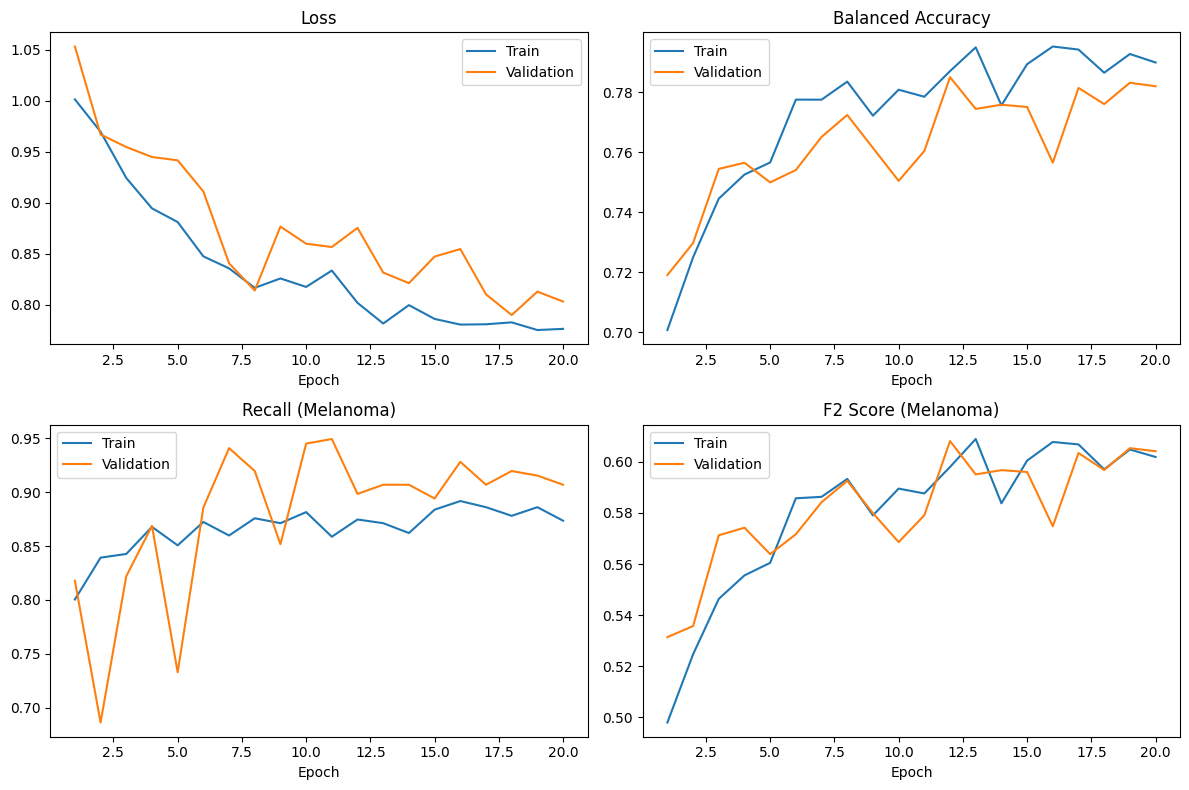

In [5]:
plot_training_curves(train_history, val_history)

### 5. Tune the Classification Threshold on the Validation Set

The loss is weighted during training, but the classification threshold still needs to be chosen separately.  
This step reloads the best saved checkpoint and finds the probability threshold that maximizes **F2 score** on the validation set.


In [6]:
model.load_state_dict(torch.load(ROOT / 'models/cnn_residual_batchnorm_weighted.pth', map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

print(f"Best validation threshold: {best_threshold:.2f}")
print(f"Best validation F2: {best_f2:.4f}")

Best threshold: 0.60 | Val F2: 0.6347
Best validation threshold: 0.60
Best validation F2: 0.6347


### 6. Evaluate on the Test Set

The best residual weighted checkpoint is evaluated on the held-out test set using the threshold selected on the validation set.  
The shared evaluation utility reports AUC-ROC, balanced accuracy, F2 score, a classification report, and visual diagnostics such as the confusion matrix and ROC curve.


Threshold:          0.60
AUC-ROC:            0.8672
Balanced Accuracy:  0.7676
F2 Score:           0.5814

              precision    recall  f1-score   support

Non-Melanoma     0.9687    0.7164    0.8237      1340
    Melanoma     0.2692    0.8187    0.4052       171

    accuracy                         0.7280      1511
   macro avg     0.6190    0.7676    0.6144      1511
weighted avg     0.8896    0.7280    0.7763      1511



/Users/joelyeo/Desktop/Deep Learning/Project/50.039-Deep-Learning/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


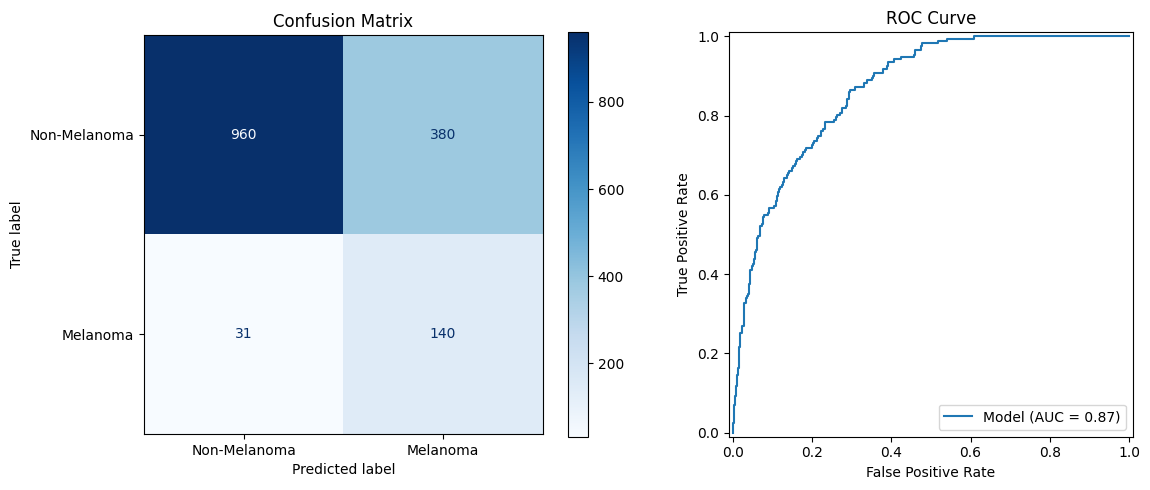

In [7]:
evaluate_model(model, test_loader, device, threshold=best_threshold)

### Results Summary (Residual BatchNorm CNN)

**Performance**
- AUC improves significantly (0.8538 → 0.8672)
- Balanced Accuracy improves (0.7456 → 0.7676)
- F2 Score improves (0.5525 → 0.5814)

**Class-wise Behavior**
- Melanoma recall increases (0.7076 → 0.8187) → strong improvement in sensitivity
- Melanoma precision decreases slightly (0.2944 → 0.2692)
- Model becomes more recall-focused, detecting more melanoma cases
- Non-melanoma accuracy decreases, leading to lower overall accuracy

**Training Behavior**
- Training remains stable with BatchNorm
- Residual connections improve gradient flow and learning effectiveness
- No strong overfitting observed

**Conclusion**
- Residual connections successfully improve feature learning
- Model is better at detecting melanoma cases
- Trade-off remains: higher recall comes with lower precision